In [167]:
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report

In [168]:
df = pd.read_csv('loan_approval_dataset.csv')

In [169]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [170]:
df.value_counts().sum()

np.int64(4269)

In [171]:
df.shape

(4269, 13)

In [172]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [173]:
df.duplicated().sum()

np.int64(0)

In [194]:
df.columns = df.columns.str.strip()
df = df.drop("loan_id", axis=1)

In [120]:
# EDA

In [ ]:
## Correlation heatmap for numerical data

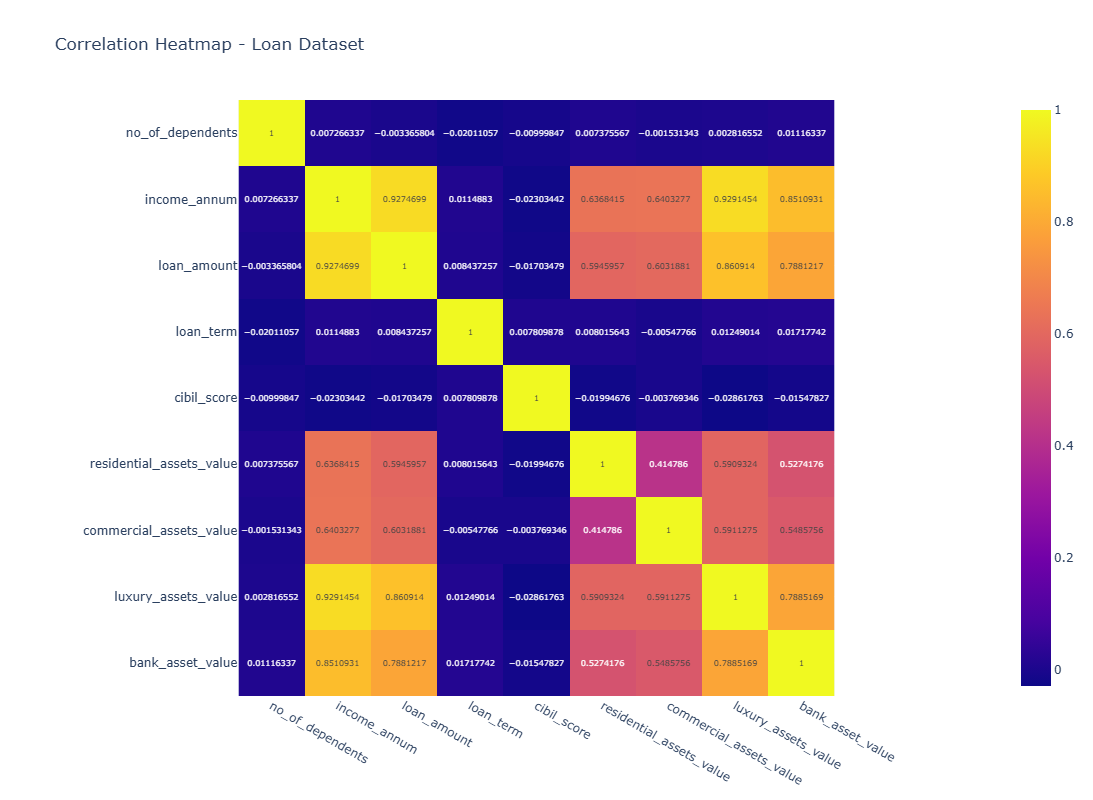

In [195]:
corr = df.corr(numeric_only=True)
fig = px.imshow(
    corr,
    text_auto=True,
    title="Correlation Heatmap - Loan Dataset"
)
fig.update_layout(
    width=900,  
    height=800  
)
fig.show()

In [ ]:
# Box Plot to detect outliers(numericals)

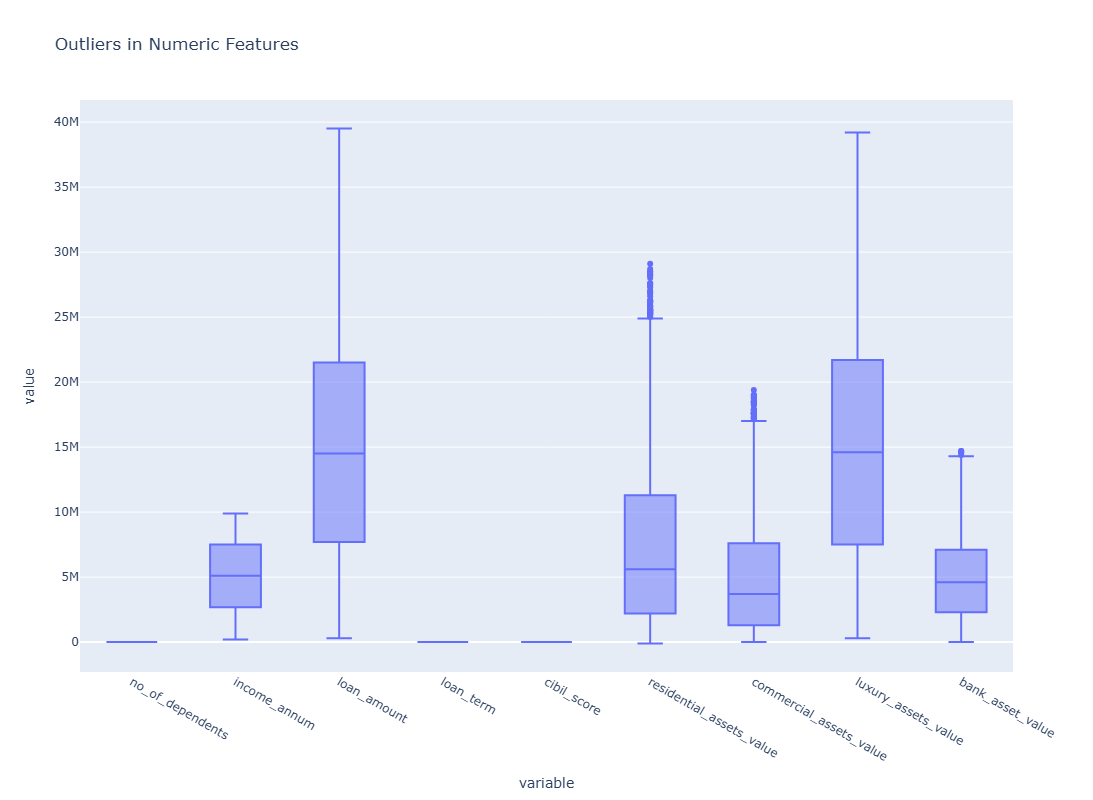

In [196]:
num_df = df.select_dtypes(include=['number'])

fig = px.box(
    num_df.melt(),
    x="variable",
    y="value",
    title="Outliers in Numeric Features"
)
fig.update_layout(

    width = 900,
    height = 800
)

fig.show()

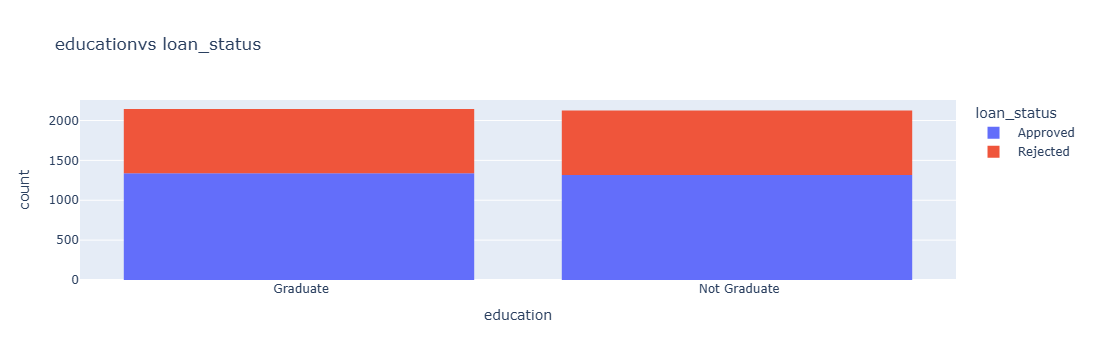

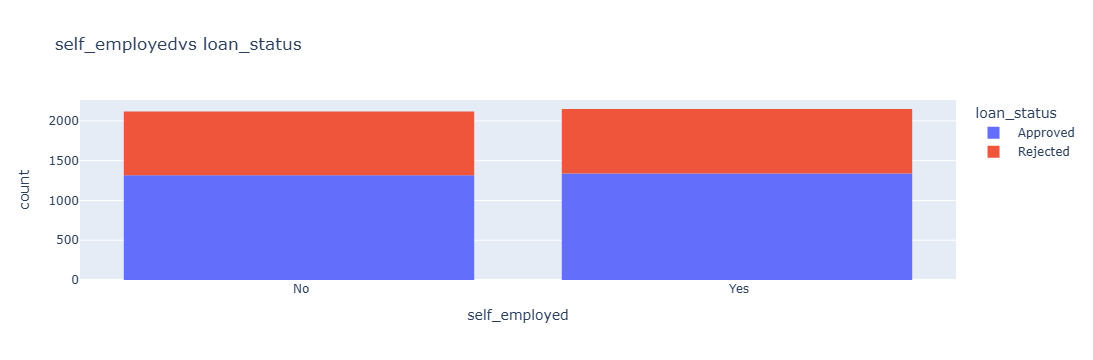

In [197]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    if col != 'loan_status':
        fig = px.histogram(df,
            x = col,
            color = 'loan_status',
            title = f"{col}vs loan_status"
        )
        fig.show()

In [198]:
df['loan_status'].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [200]:
df['loan_status'].unique()

array([' Approved', ' Rejected'], dtype=object)

In [201]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [202]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.1,random_state = 42,stratify = y)

In [203]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3842, 11)
(427, 11)
(3842,)
(427,)


In [204]:
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

In [205]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [206]:
model = RandomForestClassifier(n_estimators=200, max_depth=8,random_state=42)

In [ ]:
clf = Pipeline(steps=[("preprocessor", preprocessor),("model", model)])
clf.fit(X_train, y_train)

In [189]:
y_pred = clf.predict(X_test)

In [190]:
accuracy_score(y_test,y_pred)

0.9718969555035128

In [191]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n    Approved       0.97      0.98      0.98       266\n    Rejected       0.97      0.95      0.96       161\n\n    accuracy                           0.97       427\n   macro avg       0.97      0.97      0.97       427\nweighted avg       0.97      0.97      0.97       427\n'

In [192]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[262   4]
 [  8 153]]


In [193]:
import joblib
joblib.dump(clf,"loan_model.pkl")

['loan_model.pkl']